# Clustering : MiniBatcKMeans

Es un modelo optimizadop de K-means, donde utiliza mini-lotes de datos en lugar de todo el conjunto de datos en cada iteración, lo que reduce significativamente el tiempo de computación. 

Es ideal para:

- Datos grandes que no caben en memoria

- Aprendizaje online (progresivo)

- Cuando necesitas velocidad más que precisión máxima

Se escogio etse modelo debido a la cantidad de datos que estamos presentando que seria de 6 millones de registro de transacciones, un caso similar a lo que se tiene en la vida real, por lo que para poder optimizar este modelo se escogio justamente minibatcKmeans

Para su funcionamiento se necesita:

- Inicialización: Se seleccionan k centroides iniciales usando un pequeño subconjunto aleatorio de datos.

- Iteración con mini-lotes: En cada iteración, se toma un mini-lote pequeño muestreado aleatoriamente

- Se calcula la distancia de cada punto del mini-lote a los centroides

Cada punto se asigna al centroide más cercano

Actualización de centroides:

- Para cada centroide, se mantiene un "sum-vector" (suma de todos los puntos asignados)

- Se mantiene un "count" (número de puntos asignados)

- El nuevo centroide = sum-vector / count (el promedio)

Repetición: Se continúa hasta que los centroides convergen (no cambian significativamente)



## Por que es importante para fraudes bancarios?


1. Deteccion de anomalias: Las transacciones fraudulentas son raras y no se ajustan a los patrones normales, por lo que se le asignan a clústeres de alto riesgo y van a aparecer como un outlier que seria lejos del centroide.
2. Escalabilidad para grandes volúmenes: Permite un monitoreo en tiempo real.
3. Segmentacion por tipo de gravedad de fraude
4. Alertas Proactias
5. Aprendizaje progresio y continuo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, silhouette_score, davies_bouldin_score


Lectura de la base de datos:

In [5]:
data = pd.read_csv('../data/01_raw/PS_20174392719_1491204439457_log.csv')

Escalamiento de los datos a procesar :

Ademas que se se elimnan las columnas de nameOrig, NameDest y isFlaggeedFraud, ya que con esto el modelo puede aprender patrones de compartamiento del dia de hoy que no necesariamente se pueda repetir el dia de manana por lo que puede ocurrir un sobreajuste al momento de entrenar el modelo.

In [6]:
columnas_a_eliminar = ['nameOrig', 'nameDest', 'isFlaggedFraud'] 
df = data.drop(columns=columnas_a_eliminar, errors='ignore')

df = pd.get_dummies(df, columns=['type'], drop_first=True)

df = df.astype(np.float32)

scaler = RobustScaler() 
X_scaled = scaler.fit_transform(df)

Estableciendo los hiperparametros del modelo:

In [7]:
kmeans = MiniBatchKMeans(n_clusters=5, batch_size=10000, random_state=42)
labels = kmeans.fit_predict(X_scaled)

Se esta analizando para ver como se agruparon las deteccion de anomalias y no anomlias, en este caso serian los fraudes , y poder ver cuanto tenemos de nuestra base de dtaos.

In [8]:
distancias = kmeans.transform(X_scaled)

distancias_al_centro = distancias.min(axis=1)

df['distancia_al_centro'] = distancias_al_centro

umbral_anomalia = df['distancia_al_centro'].quantile(0.99)

df['es_anomalia'] = df['distancia_al_centro'] > umbral_anomalia

print("Transacciones normales vs Anomalías detectadas:")
print(df['es_anomalia'].value_counts())

Transacciones normales vs Anomalías detectadas:
es_anomalia
False    6298993
True       63627
Name: count, dtype: int64


Como mucho se esperaba se tiene identificadas muy pocas anomalias en las agrupaciones, de acuerdo a nuestro modelo.

In [9]:
df['cluster'] = labels

In [10]:
print(df['cluster'].value_counts())

porcentaje_ruido = (df['cluster'] == -1).mean() * 100
print(f"Porcentaje de transacciones anómalas: {porcentaje_ruido:.2f}%")

cluster
4    5281192
0     466328
3     334660
2     205258
1      75182
Name: count, dtype: int64
Porcentaje de transacciones anómalas: 0.00%


Se genera la matriz de confusion y se analiza las metricas del modelo para poder saber que tan bueno es muestro modelo de clustering.

In [11]:
y_real = data['isFraud'] 

y_pred = df['es_anomalia'] 

matriz = confusion_matrix(y_real, y_pred)
df_matriz = pd.DataFrame(
    matriz, 
    columns=['Predicción: Normal', 'Predicción: Anomalía (Fraude)'], 
    index=['Realidad: Normal', 'Realidad: Fraude']
)
print("--- Matriz de Confusión ---")
print(df_matriz)


--- Matriz de Confusión ---
                  Predicción: Normal  Predicción: Anomalía (Fraude)
Realidad: Normal             6291456                          62951
Realidad: Fraude                7537                            676


### Matriz de confusion con respecto a la clasificacion de los fraudes

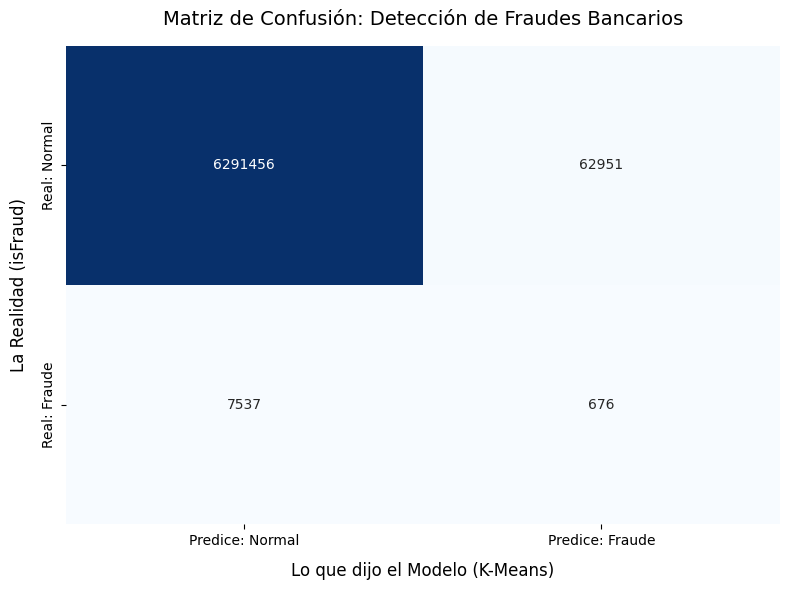

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predice: Normal', 'Predice: Fraude'],
            yticklabels=['Real: Normal', 'Real: Fraude'])

plt.title('Matriz de Confusión: Detección de Fraudes Bancarios', fontsize=14, pad=15)
plt.xlabel('Lo que dijo el Modelo (K-Means)', fontsize=12, labelpad=10)
plt.ylabel('La Realidad (isFraud)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

### Metricas del Modelo

Las metricas que se van a evaluar son : 
- Silhoutte Score: Mide que tan cerca está cada transacción de su propio grupo comparado con los demás. Sirve para evaluar la calidad individual de la asignación de cada dato.
- WCSS: La suma de las distancias al cuadrado de los puntos a su centroide. Es la métrica de batalla para encontrar el número óptimo de clústeres ($K$) mediante el Método del Codo (Elbow Method).
- Indice de Davies-Bouldin: La similitud promedio entre clústeres. Sirve como una alternativa o complemento a la Silueta para comparar diferentes configuraciones de clústeres.

### Silhouette Score

In [13]:
score_silueta = silhouette_score(X_scaled, kmeans.labels_, sample_size=10000, random_state=42)
print(f"Coeficiente de Silueta: {score_silueta:.4f}")


Coeficiente de Silueta: 0.6903


Al estar tan cerca de 0.70, significa que los clústeres están altamente definidos y muy bien separados. La gran mayoría de  las transacciones "normales" están metidas en el centro de sus respectivos grupos, y hay zonas vacías muy claras entre un grupo y otro.

### WCSS

In [14]:
inercia = kmeans.inertia_
print(f"Inercia (WCSS): {inercia:,.2f}")

Inercia (WCSS): 588,564,096.00


La inercia mide la suma de las distancias al cuadrado. Como los datos originales  tenían montos muy grandes, la escala infla este número, incluso después de aplicar. 

### Índice Davies-Bouldin

In [15]:

db_index = davies_bouldin_score(X_scaled, kmeans.labels_)
print(f"Índice Davies-Bouldin: {db_index:.4f}")

Índice Davies-Bouldin: 0.8070


Confirma que la distancia entre tus diferentes clústeres es notablemente mayor que el tamaño o dispersión interna de los propios clústeres. Lo que quiere decir es que entre nuestros clusters ay un espacio definido entre los 2 clusters, donde si un punto se aleja del clsuteer y entra a este espacio vacio se podria considerar anomalo

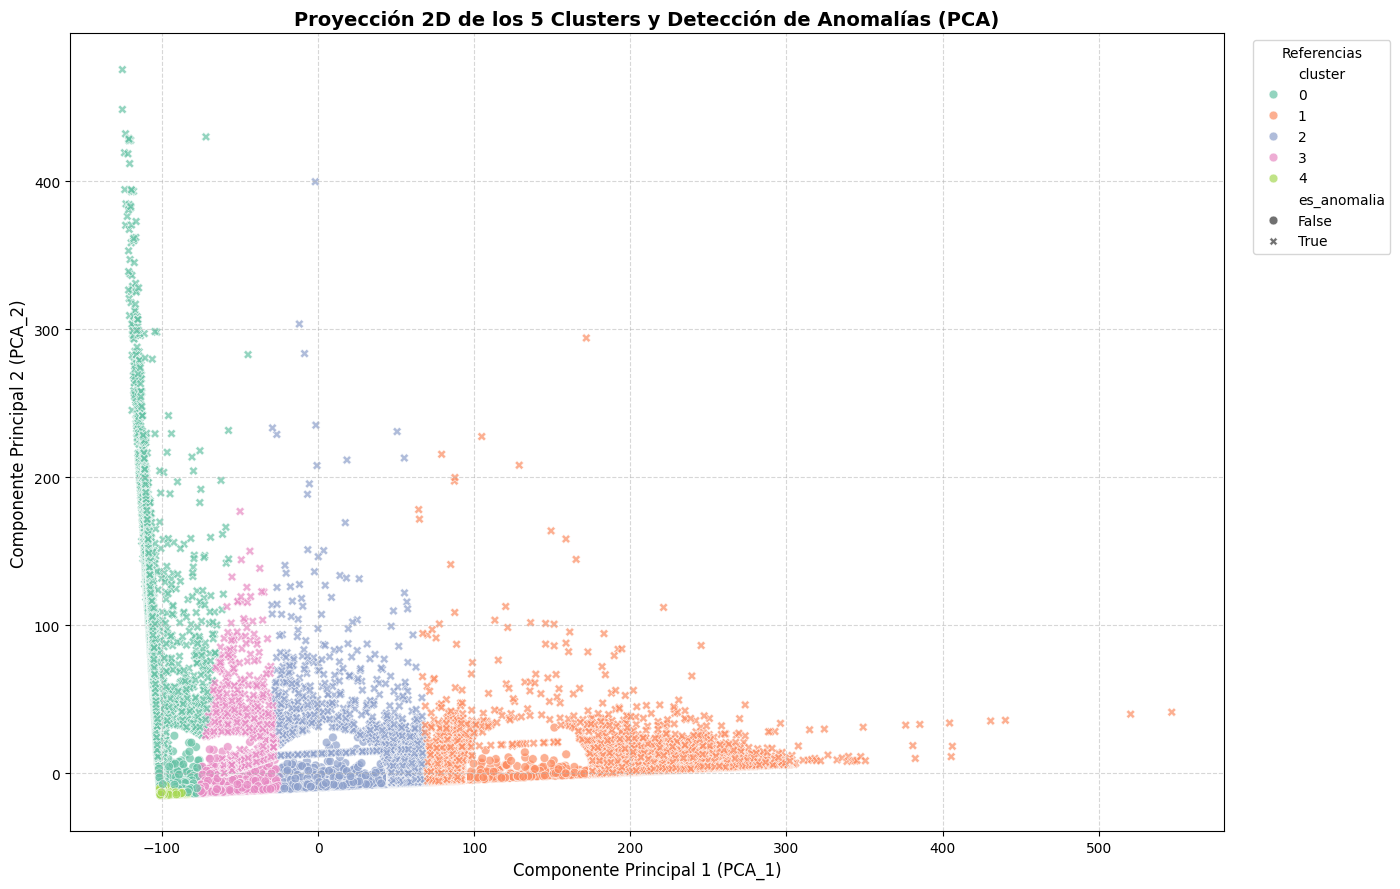

In [16]:
n_muestras = min(50000, len(df[df['es_anomalia'] == 0]))
df_normales = df[df['es_anomalia'] == 0].sample(n_muestras, random_state=42)
df_anomalias = df[df['es_anomalia'] == 1] 
df_plot = pd.concat([df_normales, df_anomalias])


columnas_excluir = ['es_anomalia', 'cluster', 'distancia_al_centro']
columnas_modelo = [col for col in df_plot.columns if col not in columnas_excluir]


X_plot_scaled = scaler.transform(df_plot[columnas_modelo])


pca = PCA(n_components=2)
componentes_2d = pca.fit_transform(X_plot_scaled)

df_plot['PCA_1'] = componentes_2d[:, 0]
df_plot['PCA_2'] = componentes_2d[:, 1]




plt.figure(figsize=(14, 9))


paleta_clusters = sns.color_palette("Set2", n_colors=5)

# 6. Graficar usando hue para Clusters y style para Anomalías
sns.scatterplot(
    data=df_plot, 
    x='PCA_1', 
    y='PCA_2', 
    hue='cluster',         
    style='es_anomalia',   
    markers={0: 'o', 1: 'X'},
    palette=paleta_clusters, 
    alpha=0.7, 
    s=40                 
)


plt.title('Proyección 2D de los 5 Clusters y Detección de Anomalías (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1 (PCA_1)', fontsize=12)
plt.ylabel('Componente Principal 2 (PCA_2)', fontsize=12)

plt.legend(title='Referencias', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Ejecutando PCA previo...
Ejecutando t-SNE (esto puede tomar 1 o 2 minutos)...


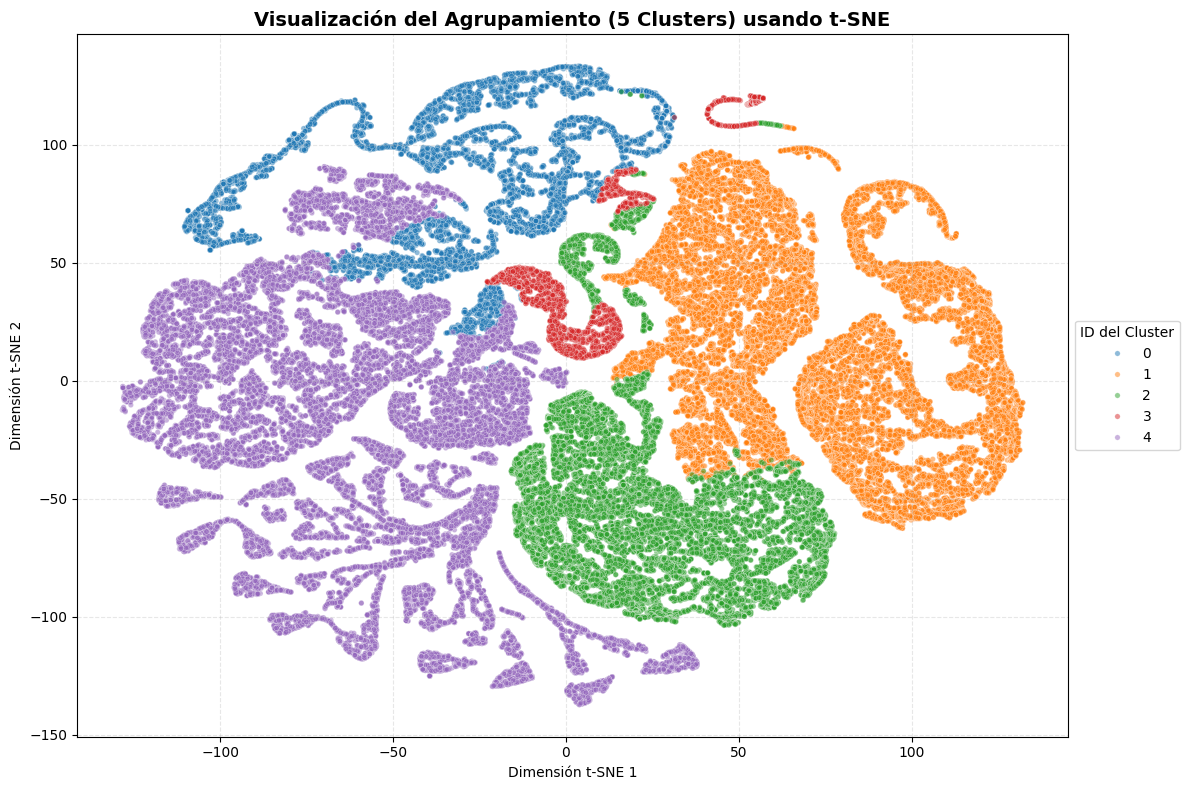

In [18]:


# 1. Muestreo de datos (Igual al anterior)
n_muestras = min(50000, len(df[df['es_anomalia'] == 0]))
df_normales = df[df['es_anomalia'] == 0].sample(n_muestras, random_state=42)
df_anomalias = df[df['es_anomalia'] == 1] 
df_plot = pd.concat([df_normales, df_anomalias])

columnas_excluir = ['es_anomalia', 'cluster', 'distancia_al_centro']
columnas_modelo = [col for col in df_plot.columns if col not in columnas_excluir]

X_plot_scaled = scaler.transform(df_plot[columnas_modelo])

# --- TRUCO DE RENDIMIENTO PARA t-SNE ---
# Reducimos primero a 30 o 50 componentes con PCA para que t-SNE no tarde horas.
print("Ejecutando PCA previo...")
pca_previo = PCA(n_components=min(30, X_plot_scaled.shape[1]))
X_pca_ready = pca_previo.fit_transform(X_plot_scaled)

# 2. Aplicar t-SNE (Ajustamos n_iter y learning_rate para acelerarlo)
print("Ejecutando t-SNE (esto puede tomar 1 o 2 minutos)...")
tsne = TSNE(
    n_components=2, 
    perplexity=40,       # Balancea la atención entre patrones locales y globales
    max_iter=1000,
    learning_rate='auto', 
    random_state=42,
    n_jobs=-1            # Utiliza todos los núcleos de tu procesador
)
componentes_tsne = tsne.fit_transform(X_pca_ready)

# Guardar los componentes en el DataFrame de graficación
df_plot['tSNE_1'] = componentes_tsne[:, 0]
df_plot['tSNE_2'] = componentes_tsne[:, 1]

# 3. Graficar el agrupamiento puro por Clusters
plt.figure(figsize=(12, 8))

# Aseguramos que la columna 'cluster' se trate como categoría para la paleta discreta
df_plot['cluster'] = df_plot['cluster'].astype(str)

sns.scatterplot(
    data=df_plot.sort_values('cluster'), # Ordenado para que no se encimen colores mal
    x='tSNE_1', 
    y='tSNE_2', 
    hue='cluster',
    palette='tab10',    # Paleta con colores muy distintos entre sí
    alpha=0.5,          # Transparencia para ver la densidad de los puntos
    s=15                # Puntos ligeramente más pequeños para t-SNE
)

plt.title('Visualización del Agrupamiento (5 Clusters) usando t-SNE', fontsize=14, fontweight='bold')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='ID del Cluster', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Distribucion de transacciones normales y anomalias

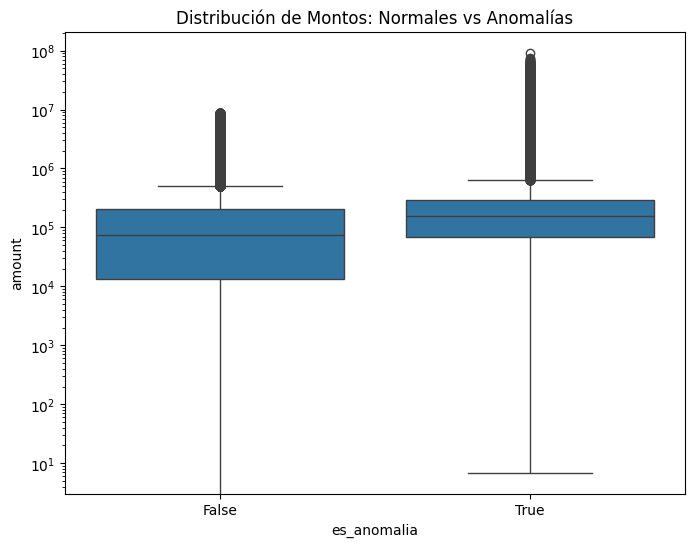

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='es_anomalia', y='amount')
plt.yscale('log')
plt.title('Distribución de Montos: Normales vs Anomalías')
plt.show()